In [ ]:
#se instala para poder separar las imagenes

In [1]:
#imports
import tensorflow as tf
import keras
import os
#librerias para el entrenamiento del modelo
from keras.models import Sequential, load_model
from keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, Input

#librerias para mostrar los cambios de la funcion loss
from keras.src.legacy.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import splitfolders #para separar el dataset en dif carpetas mientras se entrena todo
import cv2

from keras import layers, models
from keras.applications.resnet50 import preprocess_input

os.environ['CUDA_VISIBLE_DEVICES'] = "0" #para que no salga mensaje de error

I0000 00:00:1778710035.246261  205126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778710035.246837  205126 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778710035.296065  205126 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778710036.586866  205126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
input_folder = "dataset"
output_folder = "image-recognition"

In [3]:

split_ratio = (0.8, 0.1, 0.1) #80% imagenes entrenadas, 10% testing, 10% validacion


splitfolders.ratio(
    input_folder,
    output= output_folder,
    seed = 500, #para que cada ves que de dividan las imgs se haga de la misma forma
    ratio = split_ratio,
    group_prefix = None
)


In [4]:
#img_size = (130, 162)
img_size = (224, 224)

batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function= preprocess_input, #usa la funcion preprocess input de resNet50
    rotation_range=20, #rota las imagenes aleatoreamente
    width_shift_range=0.2, # mueve la imagen de izquierda a la derecha aleatoriamente
    height_shift_range=0.2, #mueve la imagen arriba o abajo aleatoriamente
    shear_range=0.2,
    zoom_range= 0.2,
    horizontal_flip=True,
    fill_mode= 'nearest'
)

In [5]:
#ambas reescalan las imagenes para que los datos se mantengan
#aumento de datos para datos de testeo
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

#aumento de datos para datos de validacion
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [6]:

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

#lee los datos de las carpetas y las prepara en tandas para entrenar el modelo
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size, 
    batch_size=batch_size,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 134 images belonging to 5 classes.


Found 25 images belonging to 5 classes.
Found 30 images belonging to 5 classes.


Este bloque de código es para ver los cambios que se le aplican a una imagen aleatoria

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..113.32].


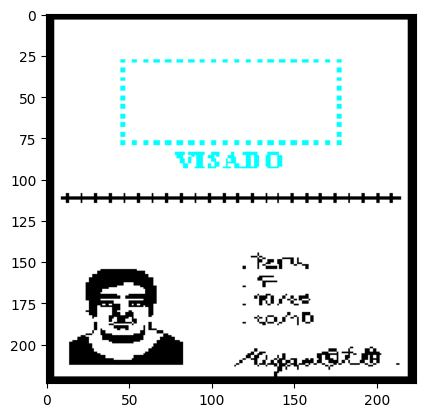

In [7]:
import random
images, labels = next(valid_data)
idx = random.randint(0,images.shape[0]-1)

plt.imshow(images[idx])
plt.show()

Configuracion del modelo a usar: ResNet50

In [8]:
from keras.applications.resnet import ResNet50 #es una cnn que esta entrenada en distintas categorias

base_model = ResNet50(weights='imagenet',include_top=False,input_shape=(img_size[0], img_size[1], 3))
#top son clasificaciones, sin el podemos poner las que se necesiten

#razones :/
base_model.trainable = False

E0000 00:00:1778710037.857819  205126 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [9]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), #ambas son fully connected layers
    layers.Dense(128, activation='relu'), #128 neuronas, con funcion de activacion relu
    layers.Dropout(0.5), # desactiva de forma aleatorea 50% de las variables de entrada
    layers.Dense(5, activation='softmax') #5 neuronas, funcion de activacion softmax
])


Compilacion del modelo

In [10]:
model.compile(optimizer='adam', #adaptive moment estimation, es eficiente
    loss='categorical_crossentropy',
    metrics=['accuracy'])

Entrenamiento del modelo

In [20]:
import scipy
model.fit(train_data, epochs=200, validation_data=valid_data)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 859ms/step - accuracy: 0.8134 - loss: 0.3759 - val_accuracy: 0.6000 - val_loss: 1.0490
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 860ms/step - accuracy: 0.8134 - loss: 0.3886 - val_accuracy: 0.6400 - val_loss: 0.8236
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 831ms/step - accuracy: 0.7985 - loss: 0.4272 - val_accuracy: 0.6000 - val_loss: 0.8350
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 863ms/step - accuracy: 0.7836 - loss: 0.4647 - val_accuracy: 0.6000 - val_loss: 1.1295
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8284 - loss: 0.4311 - val_accuracy: 0.6000 - val_loss: 1.0469
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 854ms/step - accuracy: 0.8060 - loss: 0.4213 - val_accuracy: 0.6000 - val_loss: 0.9775
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8060 - loss: 0.4295 - val_accuracy: 0.6000 - val_loss: 1.0348
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7836 - loss: 0.4245 - val_accuracy: 0.6000 - val_loss: 

Precisión final del modelo

In [27]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f'Precisión de la prueba: {test_accuracy * 100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step - accuracy: 0.6000 - loss: 0.8950
Precisión de la prueba: 60.00%


Función para predecir la categoría de la imagen

In [28]:
#aqui se definen las categorías a las que puede pertenecer las imagenes
class_names = {0: 'no-visado', 1: 'pasaporte-valido', 2: 'sin-firma', 3: 'sin-imagen', 4: 'sin-texto'}

In [29]:
def predict_img(image, model):
    test_img=cv2.imread(image)
    test_img=cv2.resize(test_img, (224,224))
    test_img=np.expand_dims(test_img, axis=0)
    result=model.predict(test_img)
    r=np.argmax(result) #valor maximo del arreglo "result"
    print(class_names[r])

In [30]:
predict_img('image-recognition/test/pasaporte-valido/psp_united_6.png', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
pasaporte-valido


In [31]:
predict_img('image-recognition/test/sin-texto/no_txt_united_1.png', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
pasaporte-valido


Despues de esto, se guarda el modelo: (vuelto comentario porque es muy pesado para github)

In [ ]:
#model.save('Verificador_Pasaportes.keras')